# Walk-forward Layer Probe 全产物展示

本 notebook 汇总 `full_history_wf_v1` 运行目录下**各 stage 的 validation 产物**与核心结论。
严格 PIT 年度扩展 fold（训练集 = 该 fold 年之前的全部、且标签在 fold 年开始前可知），
验证窗 2018–2022，**2023 final test 全程封闭**。

> 每个章节 markdown 会写明：**对应产物（文件）** 与 **可得的结论**。
> 代码只读取小的 summary/manifest 文件（KB–MB 级），不加载 3.7GB 原始预测。

In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

ROOT = Path('/home/intern_fjq_2026/Projects/chinese-wwm-roberta')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
RUN = ROOT / 'artifacts/continuous_label_layer_probe/runs/full_history_wf_v1'


def manifest(stage):
    return json.loads((RUN / stage / 'validation' / 'manifest.json').read_text())


print('run dir:', RUN)
print('stages:', sorted(p.name for p in RUN.iterdir() if p.is_dir()))

run dir: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/continuous_label_layer_probe/runs/full_history_wf_v1
stages: ['factor_validation', 'fixed_head_analysis', 'label_factor_returns', 'layer_factor_correlations', 'return_probe', 'stock_day_panel', 'walk_forward_fixed_head_label', 'walk_forward_probe', 'walk_forward_targets']


## 1. Stage 1：表示层 representations

**产物**：`representation_store_full_history_wf_v1/<hash>/` 下
`representations.npy`、`report_metadata.parquet`、`fixed_head_layer_outputs.parquet`、`representation_manifest.json`。
run 目录下有 `representation_pointer.json` 指向它。

**结论**：1,070,181 篇研报 × 13 层 × 768 维 float16（~21GB），
`layer12_equivalence` 通过（max_abs_error=0）——表示层完整有效，是后续所有 Ridge 的输入。

In [2]:
ptr = json.loads((RUN / 'representation_pointer.json').read_text())
rep_dir = Path(ptr['representation_directory'])
rm = json.loads((rep_dir / 'representation_manifest.json').read_text())
info = {k: rm.get(k) for k in ['shape', 'dtype', 'storage_dtype', 'layer12_equivalence',
                               'representation_fingerprint', 'head_recipe']}
display(pd.Series(info, name='representation_store'))

shape                                                        [1070181, 13, 768]
dtype                                                                      None
storage_dtype                                                           float16
layer12_equivalence           {'passed': True, 'rtol': 0.001, 'atol': 0.001,...
representation_fingerprint    28736d7236b72ac08b919d6ee3f2b83955fba27e5ad50b...
head_recipe                                                                None
Name: representation_store, dtype: object

## 2. 标签对齐 + 年度 fold 审计（cell 13，walk_forward_targets）

**产物**：`walk_forward_targets/validation/aligned_walk_forward_targets.parquet`（859MB，
~6.76M 行）+ `walk_forward_fold_counts.csv` + `target_source_audit.csv`。

**结论**：21 个 task 全部对齐到表示行；下表是每个 task 在每个年度 fold 的**训练行数**
（特征日早于 fold 年、且标签在 fold 年开始前可知），证明严格 PIT、训练集随 fold 年扩展。

In [3]:
fc = pd.read_csv(RUN / 'walk_forward_targets' / 'validation' / 'walk_forward_fold_counts.csv')
display(fc.pivot(index='task_id', columns='fold', values='training_rows').fillna(0).astype(int))

fold,validation_2018,validation_2019,validation_2020,validation_2021,validation_2022
task_id,,,,,
delta_log_dispersion__1m__active__fh0,92400,121896,150954,184529,213554
delta_log_dispersion__1m__active__fh1,79585,107132,134025,165302,193291
delta_log_dispersion__1m__active__fh2,28844,41073,53549,68259,83372
delta_log_dispersion__1m__fixed__fh0,138140,176771,214279,256843,295377
delta_log_dispersion__1m__fixed__fh1,121753,157643,192636,232381,269524
delta_log_dispersion__1m__fixed__fh2,54566,73505,92147,113628,135675
delta_log_dispersion__1m__market__fh0,137113,175455,212775,255157,293521
delta_log_dispersion__1m__market__fh1,120889,156555,191371,230958,267909
delta_log_dispersion__1m__market__fh2,54232,73118,91697,113144,135131


## 3. Stage 6 Scheme B Ridge（cell 17，walk_forward_probe）—— 主线核心

**产物**：`walk_forward_probe/validation/` 下
- `walk_forward_oos_predictions.parquet`（3.7GB，**45,120,764 行** OOS 预测，21 task×13 层×5 fold）
- `walk_forward_selected_alphas.csv`（273 行 = 21×13，每 task×层选定的 alpha + 平均 fold Spearman）
- `walk_forward_tuning.csv` / `walk_forward_probe_metrics.csv` / `walk_forward_eligibility.csv`

**结论**：下表是每个 task **原始 IC 最强的层**及该层 fold 平均 Spearman。
**深层（L9–12）最强**；残差/扩散度 fold Spearman ~0.05–0.10；alpha=1000 主导（病态矩阵需重正则）。
这是项目首次真正"训练 Ridge 并跨年度 OOS 预测"。

In [4]:
sa = pd.read_csv(RUN / 'walk_forward_probe' / 'validation' / 'walk_forward_selected_alphas.csv')
idx = sa.groupby('task_id')['mean_fold_spearman'].idxmax()
best = sa.loc[idx, ['task_id', 'layer', 'selected_alpha', 'mean_fold_spearman', 'valid_folds']]
best = best.sort_values('mean_fold_spearman', ascending=False)
display(best.round(4))
print('alpha 分布：')
print(sa.selected_alpha.value_counts().to_string())

,task_id,layer,selected_alpha,mean_fold_spearman,valid_folds
265,delta_log_dispersion__3m__fixed__fh1,12,1000.0,0.1032,5
226,delta_log_dispersion__3m__market__fh1,10,1000.0,0.0985,5
243,delta_log_dispersion__3m__fixed__fh0,11,1000.0,0.0968,5
234,delta_log_dispersion__1m__fixed__fh0,11,1000.0,0.0955,5
249,residual_signed_raw__fh0,11,1000.0,0.0853,4
237,delta_log_dispersion__1m__market__fh0,11,1000.0,0.0836,5
230,residual_signed_raw__fh2,10,1000.0,0.0835,2
238,delta_log_dispersion__1m__market__fh1,11,1000.0,0.0802,5
235,delta_log_dispersion__1m__fixed__fh1,11,1000.0,0.0779,5
124,residual_signed_raw__fh1,5,1000.0,0.0745,3


alpha 分布：
1000.0    249
100.0      15
10.0        5
0.1         3
1.0         1


## 4. 逐层 Spearman 曲线（plot_walk_forward_probe_curves）

**产物**：同上 `walk_forward_probe/validation`。

**结论**：每个 task 画 13 层的 pooled validation Spearman 曲线。可看到**深层（右端）普遍高于浅层**，
Layer 0（嵌入层）接近 0（常数 CLS 无信号）。

validate: {'metric_rows': 1560, 'oos_rows': 45120764, 'tasks': 21, 'folds': 5}


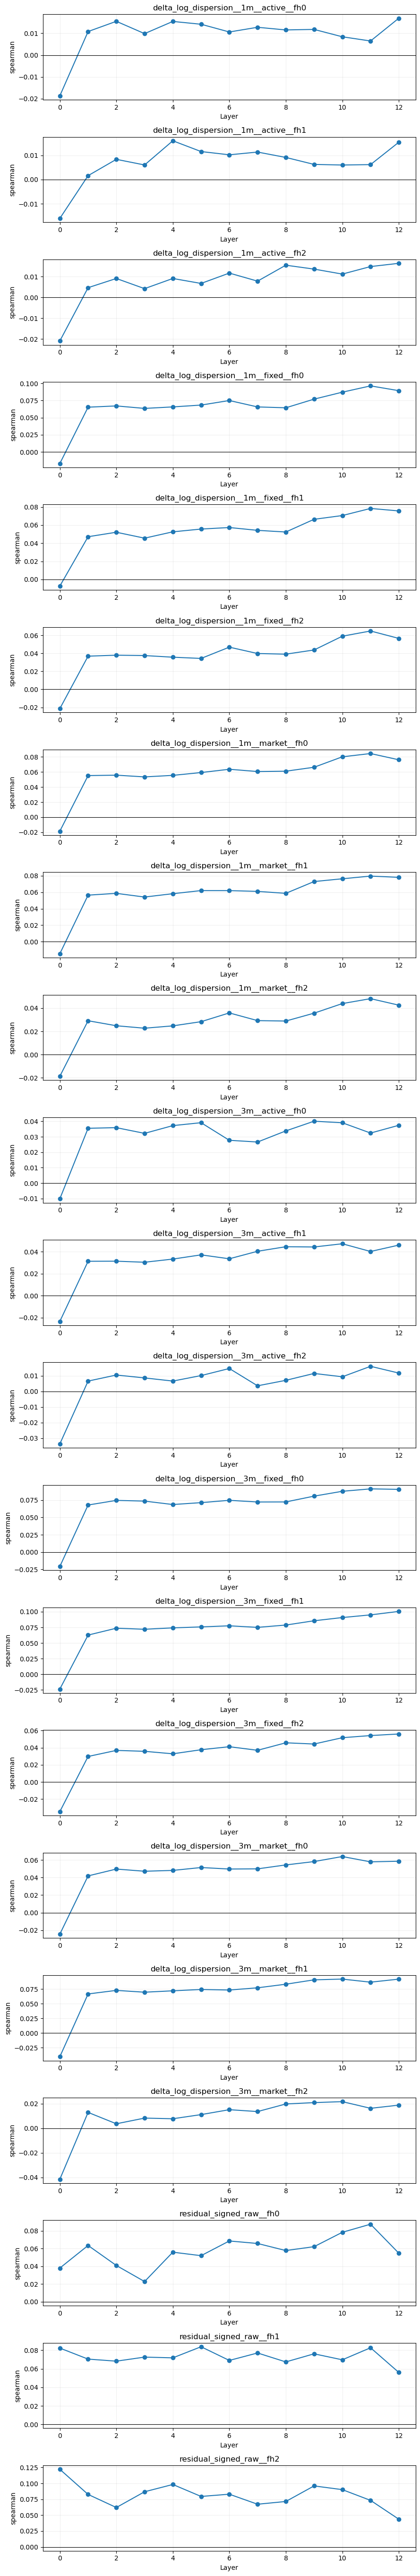

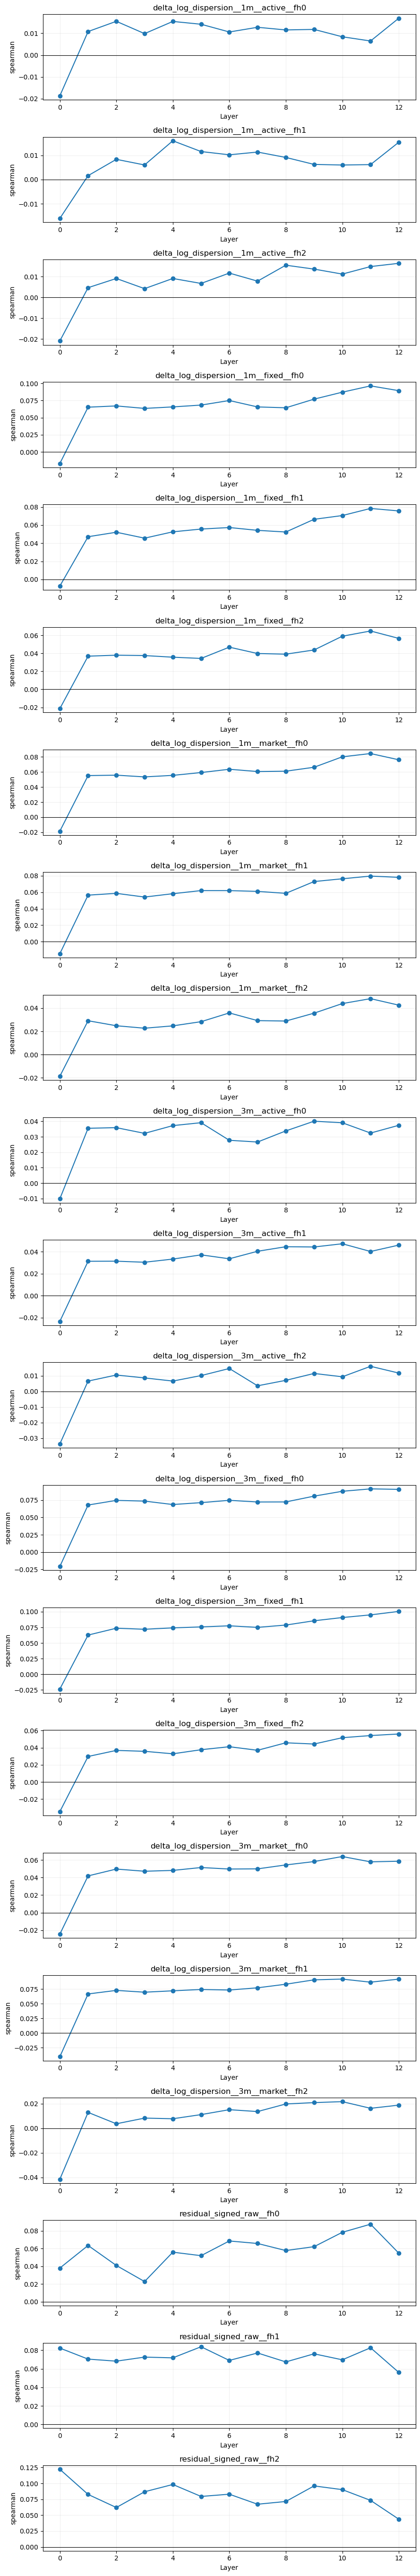

In [5]:
from src.layer_probe_walk_forward import plot_walk_forward_probe_curves, validate_walk_forward_probe_outputs
print('validate:', validate_walk_forward_probe_outputs(RUN / 'walk_forward_probe' / 'validation'))
plot_walk_forward_probe_curves(RUN / 'walk_forward_probe' / 'validation')

## 5. 直接收益 probe（cell 21，return_probe）

**产物**：`return_probe/validation/` 下 `return_oos_predictions.parquet`（70MB，2,379,507 行）
+ `return_fit_reference_predictions.parquet`（97MB）+ `return_probe_metrics.csv` + `return_probe_tuning.csv`。

**结论**：直接用股票日表示预测 5 日收益 rank（Ridge，cholesky）。
这一路比"连续标签→收益"路径强得多（见后 cell 27：直接收益共识因子 IC ~0.11，vs 标签路径 ~0.02）。

In [6]:
rp = pd.read_csv(RUN / 'return_probe' / 'validation' / 'return_probe_metrics.csv')
display(rp.round(4))

,layer,split,selected_alpha,rank_ic,ic_std,icir,t_stat,positive_fraction,n_days,icir_annualized
0,0,validation,1000.0,NaN,NaN,NaN,NaN,NaN,0,NaN
1,1,validation,1000.0,0.0920,0.1017,0.9046,27.9122,0.8382,952,14.3607
2,2,validation,1000.0,0.0800,0.0985,0.8115,25.0376,0.7994,952,12.8818
3,3,validation,100.0,0.0848,0.1023,0.8289,25.5747,0.8225,952,13.1581
4,4,validation,1000.0,0.0897,0.0995,0.9021,27.8347,0.8340,952,14.3208
5,5,validation,1000.0,0.0946,0.1006,0.9404,29.0169,0.8382,952,14.9291
6,6,validation,100.0,0.0992,0.1014,0.9779,30.1723,0.8424,952,15.5235
7,7,validation,1000.0,0.0959,0.1025,0.9352,28.8565,0.8330,952,14.8466
8,8,validation,1000.0,0.0917,0.0980,0.9365,28.8941,0.8330,952,14.8659
9,9,validation,1000.0,0.1049,0.1057,0.9925,30.6216,0.8414,952,15.7547


## 6. 标签因子收益 + 增量 IC（cell 23，label_factor_returns）—— 覆盖度剥离（你最初的核心担忧）

**产物**：`label_factor_returns/validation/` 下
- `label_factor_stock_day.parquet`（519MB，24.5M 行，聚合到股票日的标签预测 + 前瞻收益 + n_texts/fixed_head_margin）
- `label_factor_summary.csv`（819 行 = 21×13×3 horizon，**原始日度 Rank IC + HAC t + BH q**）
- `label_factor_incremental_daily_ic.parquet`（819 行汇总，文件名互换；**增量 IC = 控制 fixed_head_margin + log(n_texts) 后的 partial Rank IC**）
- `label_factor_daily_ic.parquet` / `label_factor_stratified_ic.csv` / `label_factor_quantile_*` / `realized_label_return_diagnostic.csv`

**结论**：下表每 task 取原始 IC 最强层，对比 **原始 IC vs 剥覆盖度后的增量 IC**。
**真信号保留住了**：多数 task 保留 77–131%，几个反升（controls 在遮蔽而非驱动）；L0 的"信号"被正确剔除（保留 3–13%）。

In [7]:
raw = pd.read_csv(RUN / 'label_factor_returns' / 'validation' / 'label_factor_summary.csv')
# 注意：增量 IC 的 819 行汇总实际存在 label_factor_incremental_daily_ic.parquet（命名互换）
inc = pd.read_parquet(RUN / 'label_factor_returns' / 'validation' / 'label_factor_incremental_daily_ic.parquet')
for h in [5, 1, 20]:
    r = raw[raw.horizon == h]
    i = inc[inc.horizon == h]
    idx = r.groupby('task_id')['rank_ic'].idxmax()
    b = r.loc[idx, ['task_id', 'layer', 'rank_ic', 'hac_t_stat', 'n_days']].rename(
        columns={'rank_ic': 'raw_ic', 'hac_t_stat': 'raw_t'})
    m = b.merge(i[['task_id', 'layer', 'rank_ic', 'hac_t_stat']].rename(
        columns={'rank_ic': 'inc_ic', 'hac_t_stat': 'inc_t'}), on=['task_id', 'layer'])
    m['retain_pct'] = (m.inc_ic / m.raw_ic * 100).round(0)
    print(f'--- horizon {h}d（per-task 原始最强层）---')
    display(m.sort_values('raw_ic', ascending=False).round(4)[
        ['task_id', 'layer', 'raw_ic', 'inc_ic', 'retain_pct', 'raw_t', 'inc_t', 'n_days']])

--- horizon 5d（per-task 原始最强层）---


,task_id,layer,raw_ic,inc_ic,retain_pct,raw_t,inc_t,n_days
16,delta_log_dispersion__3m__market__fh1,11,0.0274,0.0289,105.0,6.2029,6.7766,1149
18,residual_signed_raw__fh0,3,0.0242,0.0192,79.0,5.8667,4.7243,973
7,delta_log_dispersion__1m__market__fh1,12,0.0241,0.0238,99.0,4.9660,4.9688,1173
0,delta_log_dispersion__1m__active__fh0,1,0.0237,0.0183,77.0,4.5893,3.4588,1016
10,delta_log_dispersion__3m__active__fh1,11,0.0214,0.0185,87.0,5.1535,4.5406,1142
9,delta_log_dispersion__3m__active__fh0,12,0.0187,0.0152,81.0,4.3330,3.4051,1063
19,residual_signed_raw__fh1,0,0.0158,0.0012,7.0,2.0943,0.4061,169
2,delta_log_dispersion__1m__active__fh2,0,0.0156,0.0111,71.0,1.6747,2.0319,283
4,delta_log_dispersion__1m__fixed__fh1,12,0.0134,0.0129,96.0,2.7383,2.7152,1174
1,delta_log_dispersion__1m__active__fh1,4,0.0128,0.0076,59.0,2.4003,1.3602,1027


--- horizon 1d（per-task 原始最强层）---


,task_id,layer,raw_ic,inc_ic,retain_pct,raw_t,inc_t,n_days
18,residual_signed_raw__fh0,0,0.0236,0.0007,3.0,4.5421,0.2356,407
10,delta_log_dispersion__3m__active__fh1,3,0.0219,0.0173,79.0,5.5403,4.3483,1142
19,residual_signed_raw__fh1,0,0.0215,0.0043,20.0,2.5219,1.4407,169
9,delta_log_dispersion__3m__active__fh0,11,0.0207,0.0191,92.0,4.9977,4.5654,1063
17,delta_log_dispersion__3m__market__fh2,0,0.0205,-0.0030,-14.0,1.7414,-0.8784,136
1,delta_log_dispersion__1m__active__fh1,0,0.0203,0.0031,15.0,1.6831,0.9486,143
0,delta_log_dispersion__1m__active__fh0,1,0.0202,0.0127,63.0,4.0635,2.4817,1016
7,delta_log_dispersion__1m__market__fh1,6,0.0190,0.0161,85.0,4.6502,3.8809,1173
16,delta_log_dispersion__3m__market__fh1,11,0.0182,0.0183,101.0,4.5028,4.5155,1149
13,delta_log_dispersion__3m__fixed__fh1,0,0.0170,0.0036,21.0,3.5205,0.9921,810


--- horizon 20d（per-task 原始最强层）---


,task_id,layer,raw_ic,inc_ic,retain_pct,raw_t,inc_t,n_days
16,delta_log_dispersion__3m__market__fh1,11,0.0238,0.0240,101.0,4.9496,5.1118,1149
7,delta_log_dispersion__1m__market__fh1,12,0.0232,0.0239,103.0,4.0736,4.1437,1173
8,delta_log_dispersion__1m__market__fh2,12,0.0209,0.0213,102.0,3.0482,3.2254,820
9,delta_log_dispersion__3m__active__fh0,11,0.0202,0.0190,94.0,3.7750,3.6104,1063
5,delta_log_dispersion__1m__fixed__fh2,8,0.0199,0.0194,98.0,2.9677,3.0565,820
0,delta_log_dispersion__1m__active__fh0,12,0.0184,0.0207,112.0,2.5183,2.8721,1016
10,delta_log_dispersion__3m__active__fh1,10,0.0179,0.0148,82.0,4.1985,3.6079,1142
2,delta_log_dispersion__1m__active__fh2,0,0.0175,0.0126,72.0,1.9349,1.9769,283
4,delta_log_dispersion__1m__fixed__fh1,2,0.0160,0.0143,89.0,2.7602,2.5026,1174
17,delta_log_dispersion__3m__market__fh2,11,0.0148,0.0168,114.0,2.1157,2.4416,860


## 7. 标签因子逐层 IC 曲线（plot_label_factor_ic_curves）

**产物**：同上 `label_factor_returns/validation`。

**结论**：每个 task 画 13 层的 5 日 Rank IC。深层普遍更高，L0 塌到 0。

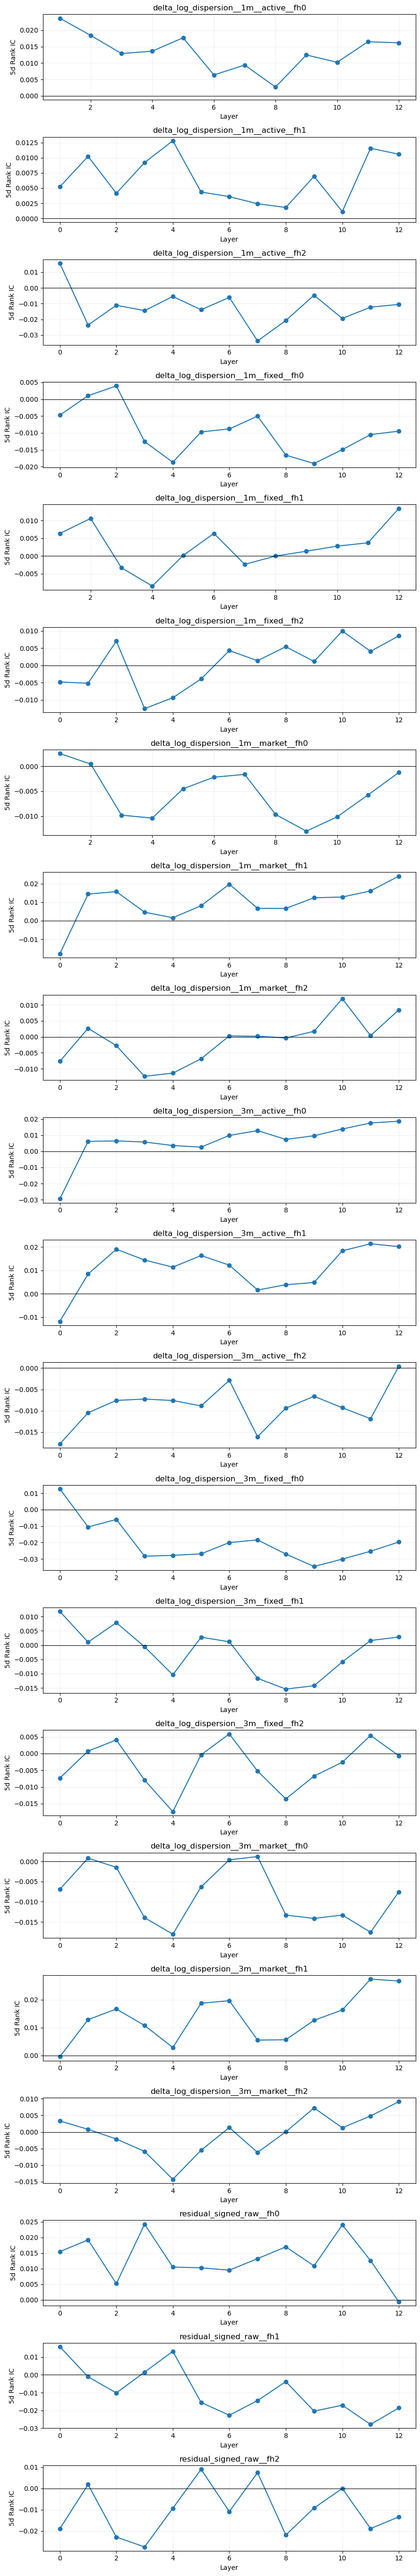

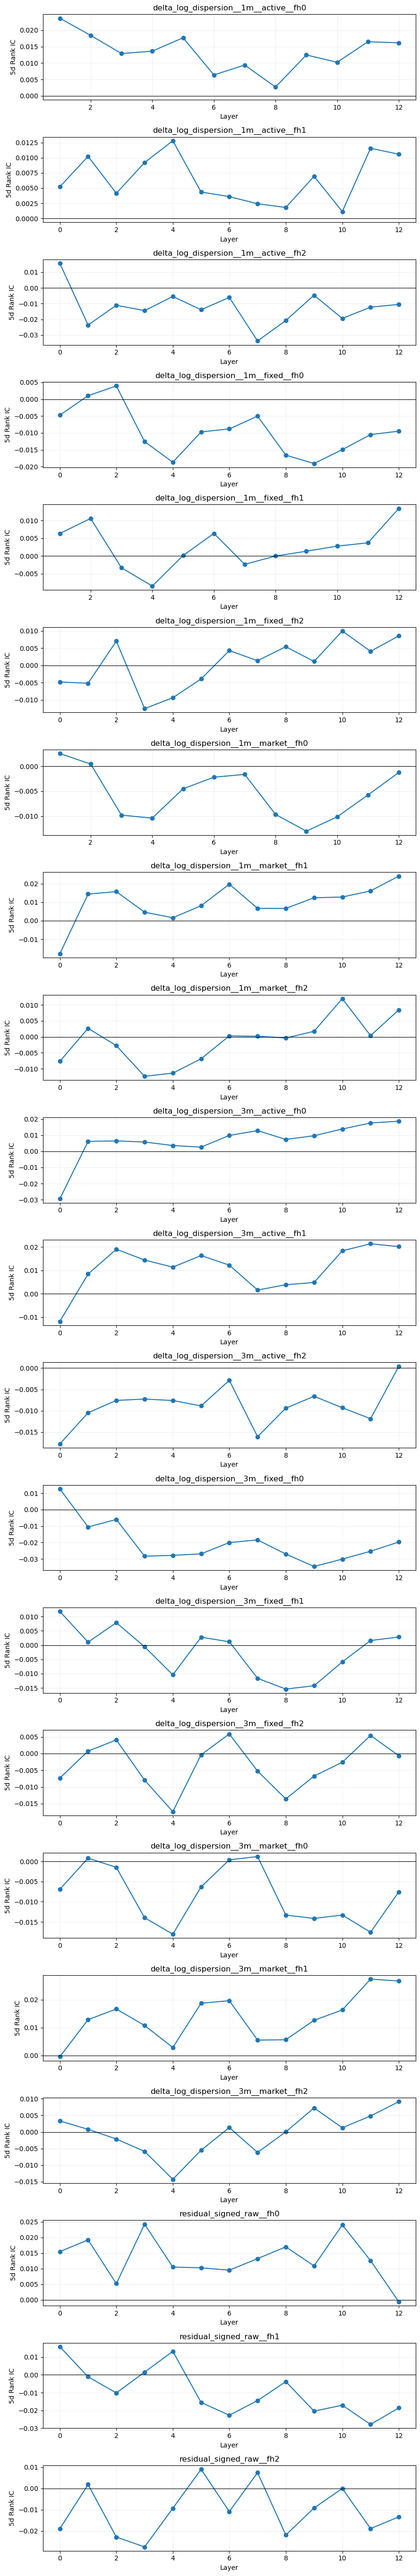

In [8]:
from src.layer_probe_label_factors import plot_label_factor_ic_curves
plot_label_factor_ic_curves(RUN / 'label_factor_returns' / 'validation', horizon=5)

## 8. 层间相关（cell 25，layer_factor_correlations）

**产物**：`layer_factor_correlations/validation/` 下
`daily_layer_correlations.parquet`（12MB，2,110,381 日行）+ `layer_correlation_summary.csv`（2002 行）。

**结论**：逐日 13×13 截面 Spearman 的均值。相邻层高度相关，深层彼此相关更强——
这也是为什么 `layer_consensus` / `layer_pca_1`（下一节）能几乎捕获全部信号。

In [9]:
lc = pd.read_csv(RUN / 'layer_factor_correlations' / 'validation' / 'layer_correlation_summary.csv')
display(lc.head(20).round(3))

,factor_source,task_id,layer_left,layer_right,mean_spearman,median_spearman,std_spearman,n_days,mean_n_obs
0,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,0,NaN,NaN,NaN,0,65.867
1,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,1,NaN,NaN,NaN,0,65.867
2,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,2,NaN,NaN,NaN,0,65.867
3,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,3,NaN,NaN,NaN,0,65.867
4,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,4,NaN,NaN,NaN,0,65.867
5,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,5,NaN,NaN,NaN,0,65.867
6,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,6,NaN,NaN,NaN,0,65.867
7,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,7,NaN,NaN,NaN,0,65.867
8,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,8,NaN,NaN,NaN,0,65.867
9,continuous_label_probe,delta_log_dispersion__1m__active__fh0,0,9,NaN,NaN,NaN,0,65.867


## 8b. 层相关热力图（plot_layer_correlation_heatmap）

**产物**：同上。

**结论**：残差 task 与直接收益 task 的 13×13 平均 Spearman 热力图。对角线=1，深层块更亮。

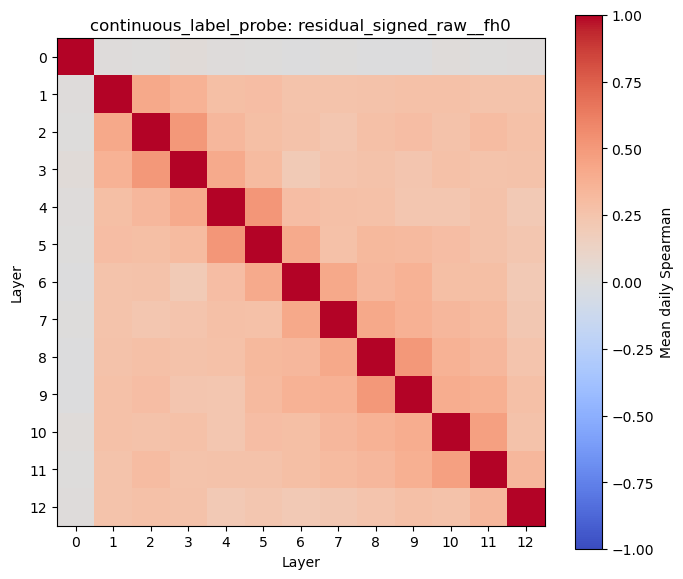

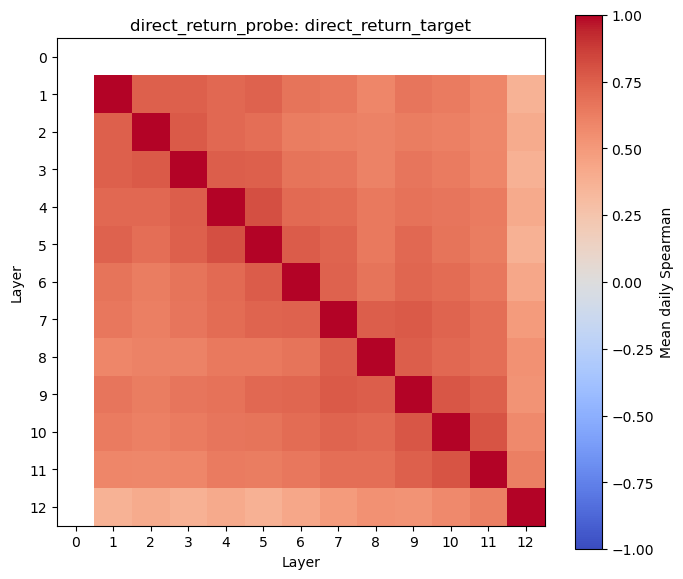

In [10]:
from src.layer_probe_label_factors import plot_layer_correlation_heatmap
for fs, t in [('continuous_label_probe', 'residual_signed_raw__fh0'),
              ('direct_return_probe', 'direct_return_target')]:
    try:
        plot_layer_correlation_heatmap(RUN / 'layer_factor_correlations' / 'validation',
                                       factor_source=fs, task_id=t)
        plt.show()
    except Exception as e:
        print(fs, t, '跳过:', e)

## 9. 合成因子（cell 27，factor_validation）—— 最强信号

**产物**：`factor_validation/validation/` 下
- `candidate_factor_matrix.parquet`（39MB，183,039 行，20 个候选因子：single_layer_0-12、layer_consensus、layer_disagreement、deep_minus_middle、deep_residual、layer_pca_1-3）
- `factor_summary.csv`（20 行，每个因子的 Rank IC/ICIR/HAC t/BH q）
- `incremental_ic.csv`（20 行，**增量 IC = 剥 fixed_head_margin+log(n_texts)**）
- `daily_rank_ic.csv` / `stratified_ic.csv` / `quantile_group_returns.csv` / `quantile_monotonicity.csv`

**结论**：`layer_consensus`（13 层均值，**scale 已对齐**）5 日 IC **0.111、HAC t=25.7**，最强；
`layer_pca_1` 几乎相同（PCA 第一主成分=共识信号）。
**剥覆盖度后保留 90%（t=22.9）**——真实、统计极显著、抗覆盖度剥离。
single 层峰值在 L6–L11（~0.10），L0 无信号（NaN）。

In [11]:
fs = pd.read_csv(RUN / 'factor_validation' / 'validation' / 'factor_summary.csv')
inc = pd.read_csv(RUN / 'factor_validation' / 'validation' / 'incremental_ic.csv')
m = fs[['factor', 'rank_ic', 'icir', 'hac_t_stat', 'hac_pvalue', 'qvalue_bh']].merge(
    inc[['factor', 'rank_ic', 'hac_t_stat']].rename(columns={'rank_ic': 'inc_ic', 'hac_t_stat': 'inc_t'}),
    on='factor')
m['retain_pct'] = (m.inc_ic / m.rank_ic * 100).round(0)
print('5d 合成因子：原始 IC vs 增量 IC（剥覆盖度）')
display(m.sort_values('rank_ic', ascending=False).round(4))

5d 合成因子：原始 IC vs 增量 IC（剥覆盖度）


,factor,rank_ic,icir,hac_t_stat,hac_pvalue,qvalue_bh,inc_ic,inc_t,retain_pct
13,layer_consensus,0.1107,1.0651,25.7141,0.0000,0.0000,0.0998,22.9423,90.0
17,layer_pca_1,0.1106,1.0645,25.7053,0.0000,0.0000,0.0998,22.9309,90.0
10,single_layer_10,0.1073,1.0092,23.9555,0.0000,0.0000,0.0981,22.2812,91.0
11,single_layer_11,0.1070,1.0059,23.9326,0.0000,0.0000,0.0992,22.4793,93.0
9,single_layer_9,0.1049,0.9925,24.1747,0.0000,0.0000,0.0955,21.9625,91.0
6,single_layer_6,0.0992,0.9779,24.5812,0.0000,0.0000,0.0889,22.3201,90.0
7,single_layer_7,0.0959,0.9352,24.0862,0.0000,0.0000,0.0864,21.7814,90.0
5,single_layer_5,0.0946,0.9404,23.8760,0.0000,0.0000,0.0842,21.0828,89.0
1,single_layer_1,0.0920,0.9046,23.6626,0.0000,0.0000,0.0808,21.0116,88.0
8,single_layer_8,0.0917,0.9365,23.2558,0.0000,0.0000,0.0836,21.0770,91.0


## 10. 合成因子 IC 条形图（plot_factor_summary）

**产物**：同上 `factor_validation/validation`。

**结论**：一眼看全 20 个因子的 5 日 Rank IC。consensus/PCA_1 顶在最前。

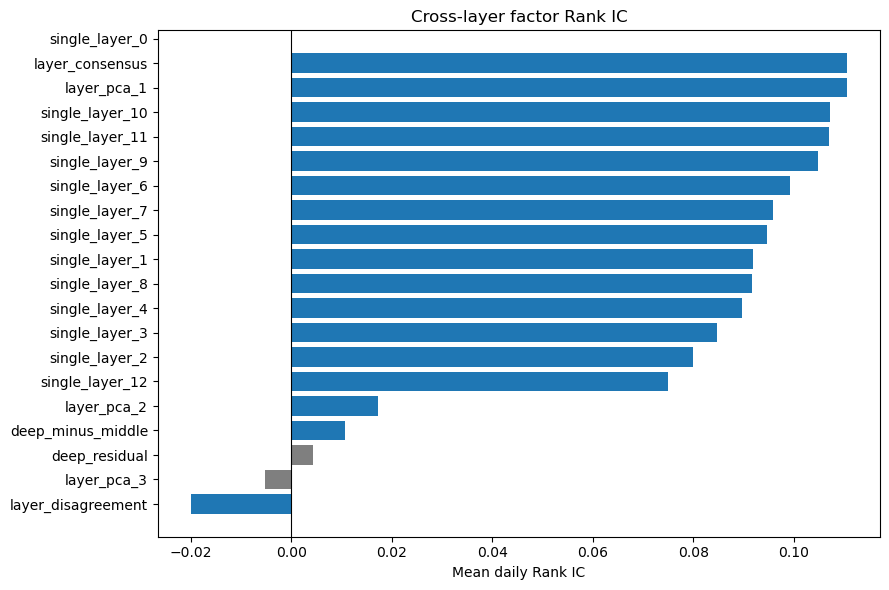

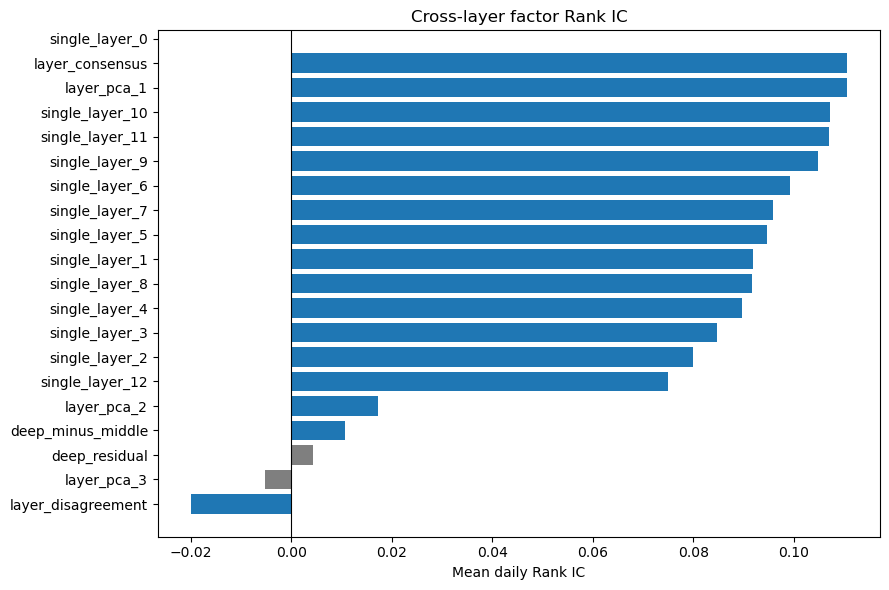

In [ ]:
from src.layer_probe_pipeline import plot_factor_summary
plot_factor_summary(RUN / 'factor_validation' / 'validation')

## 11. 可靠性：manifest 哈希链 + 2023 测试集封闭

**产物**：每个 stage 目录的 `manifest.json`（含 schema_version + 上游 sha256 指纹），
run 根目录若无 `FINAL_TEST_OPENED.json` 即 2023 测试集封闭。

**结论**：5 个 stage schema 链一致、`partial=False`、`final_test_rows_loaded=False`、
无 `FINAL_TEST_OPENED.json` → **2023 final test 全程封闭，本轮全部为 validation OOS**，
结果无前视泄漏。

In [13]:
rows = []
for s in ['walk_forward_probe', 'return_probe', 'label_factor_returns',
          'layer_factor_correlations', 'factor_validation']:
    m = manifest(s)
    rows.append({'stage': s, 'schema': m.get('schema_version'), 'partial': m.get('partial'),
                 'final_test_loaded': m.get('final_test_rows_loaded'), 'solver': m.get('solver')})
display(pd.DataFrame(rows))
sealed = not (RUN / 'FINAL_TEST_OPENED.json').exists()
print('FINAL_TEST_OPENED.json 存在:', not sealed, '→ 2023 测试集', '已开' if not sealed else '封闭')

,stage,schema,partial,final_test_loaded,solver
0,walk_forward_probe,walk_forward_continuous_probe_v1.0,False,False,cholesky
1,return_probe,return_layer_probe_v2.0,None,None,None
2,label_factor_returns,continuous_label_stock_day_factor_v1.0,None,None,None
3,layer_factor_correlations,layer_factor_correlation_v1.0,None,None,None
4,factor_validation,cross_layer_factor_validation_v2.0,None,None,None


FINAL_TEST_OPENED.json 存在: False → 2023 测试集 封闭


---

## 一句话总结

冻结中文 RoBERTa 的研报表示，经严格 PIT 年度扩展 walk-forward 检验：
**直接收益的多层共识因子 IC ~0.11（HAC t=25.7），剥掉研报覆盖度/冻结头方向后保留 90%——
研报文本带真实的、统计极显著的、非 attention 假象的 5 日收益预测信号**，
深层（L6–12）携带主要信息，Layer 0（嵌入层）无信号，2023 测试集保持封闭待预注册后开启。